In [1]:
## Becca's boundary conditions

In [23]:
import gsw
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [50]:
data18 = xr.open_dataset('LiveOcean_v201905_y2019m02d18.nc')
data19 = xr.open_dataset('LiveOcean_v201905_y2019m02d19.nc')

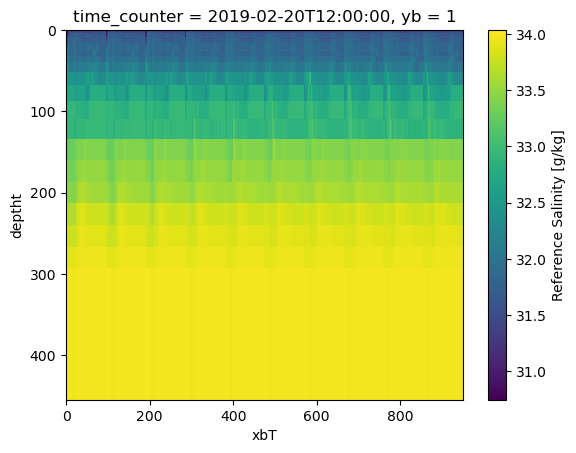

In [6]:
data19.vosaline[0, :, 0].plot(yincrease=False)

In [14]:
diffy = np.array(data19.vosaline[0, 1:, 0]) - np.array(data19.vosaline[0, :-1, 0])

In [89]:
print (diffy.max(), diffy[:15, 100:200].min())

0.6956672723751431 -0.5141484170252788


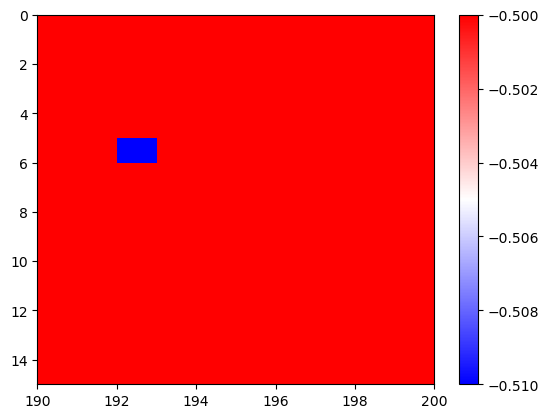

In [93]:
fig, ax = plt.subplots(1, 1)
colours = ax.pcolormesh(diffy, cmap='bwr', vmax=-0.5, vmin=-0.51)
ax.invert_yaxis()
ax.set_xlim(190, 200)
ax.set_ylim(15, 0)
fig.colorbar(colours, ax=ax);

In [51]:
print (diffy[7, 0], data19.vosaline[0, 7, 0, 0].values, data19.vosaline[0, 8, 0, 0].values)
print (data18.vosaline[0, 7, 0, 0].values, data18.vosaline[0, 8, 0, 0].values)

-0.4605930436303467 31.598990209428425 31.13839716579808
30.6308756177476 30.98222183662927


In [70]:
print (diffy[7, 95], data19.vosaline[0, 7, 0, 95].values, data19.vosaline[0, 8, 0, 95].values)
print (data18.vosaline[0, 7, 0, 95].values, data18.vosaline[0, 8, 0, 95].values)

-0.40149522520348313 31.510092675341443 31.10859745013796
30.631875617747596 30.975089601039862


In [96]:
print (diffy[7, 98], data19.vosaline[0, 7, 0, 98].values, data19.vosaline[0, 8, 0, 98].values)
print (data18.vosaline[0, 7, 0, 98].values, data18.vosaline[0, 8, 0, 98].values)

-0.3919404745622863 31.689074860128795 31.29713438556651
30.63483628616415 31.0019328178304


In [98]:
print (diffy[5, 192], data19.vosaline[0, 5, 0, 192].values, data19.vosaline[0, 6, 0, 192].values)
print (data18.vosaline[0, 5, 0, 192].values, data18.vosaline[0, 5, 0, 192].values)

-0.5141484170252788 31.499208293490245 30.985059876464966
30.764386799669868 30.764386799669868


In [52]:
print (data19.votemper[0, 7, 0, 0].values, data19.votemper[0, 8, 0, 0].values)
print (data18.votemper[0, 7, 0, 0].values, data18.votemper[0, 8, 0, 0].values)

10.225241582502003 7.781989146234978
8.168528339388505 9.350251345795503


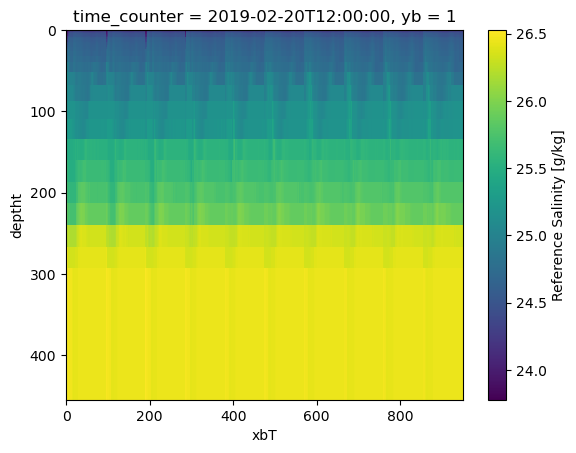

In [31]:
density = gsw.sigma0(data19.vosaline[0, :, 0], data19.votemper[0, :, 0])
density.plot(yincrease=False);

In [27]:
diff_dens = np.array(density[1:]) - np.array(density[:-1])

In [34]:
print (diff_dens.max(), diff_dens.min())

0.5337116480700388 0.0


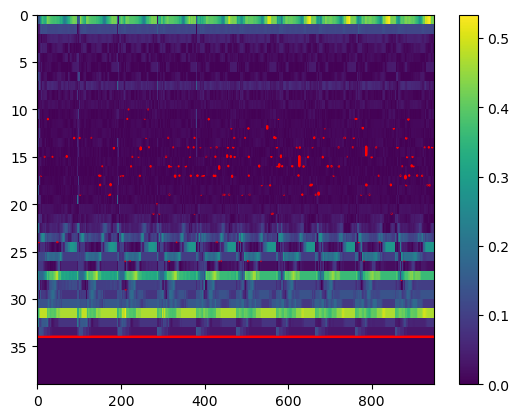

In [44]:
fig, ax = plt.subplots(1, 1)
colours = ax.pcolormesh(diff_dens)#, vmax=0.5, vmin=-0.5)
ax.invert_yaxis()
ax.contour(diff_dens, levels=[0, 0.001], colors=['r'])
fig.colorbar(colours, ax=ax);

In [118]:
def time_change(dd, ll, data19, data18):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for it in range(-12, 12):
        ratio = (it+12)/24
        salinity_above = ratio*data19.vosaline[0, dd, 0, ll].values + (1-ratio)*data18.vosaline[0, dd, 0, ll].values
        salinity_below = ratio*data19.vosaline[0, dd+1, 0, ll].values + (1-ratio)*data18.vosaline[0, dd+1, 0, ll].values
        temperature_above = ratio*data19.votemper[0, dd, 0, ll].values + (1-ratio)*data18.votemper[0, dd, 0, ll].values
        temperature_below = ratio*data19.votemper[0, dd+1, 0, ll].values + (1-ratio)*data18.votemper[0, dd+1, 0, ll].values
        density_above = gsw.sigma0(salinity_above, temperature_above)
        density_below = gsw.sigma0(salinity_below, temperature_below)
        axs[0].plot(it, salinity_above, 'bo')
        axs[0].plot(it, salinity_below, 'ro')
        axs[1].plot(it, temperature_above, 'bo')
        axs[1].plot(it, temperature_below, 'ro')
        axs[2].plot(it, density_above, 'bo')
        axs[2].plot(it, density_below, 'ro')
    return axs

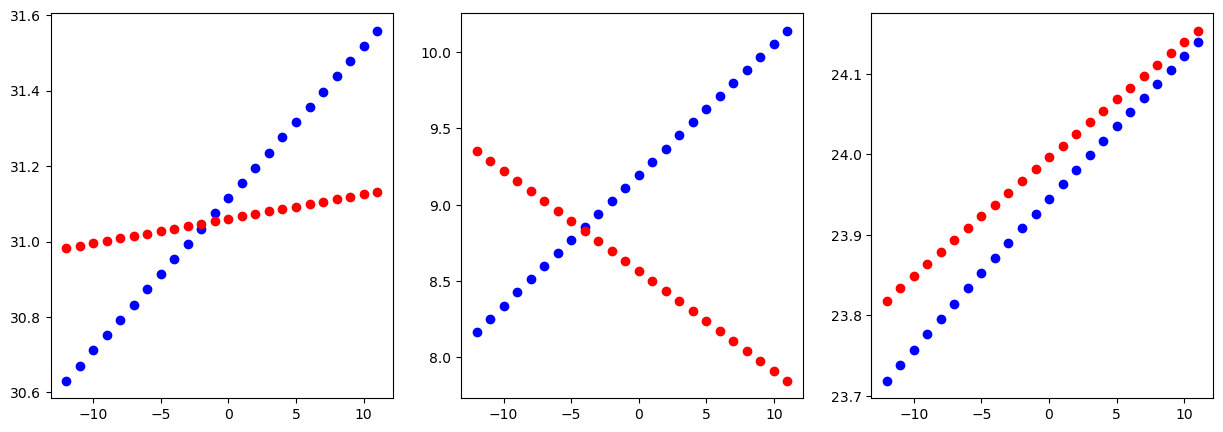

In [62]:
dd, ll = 7, 0
time_change(dd, ll)

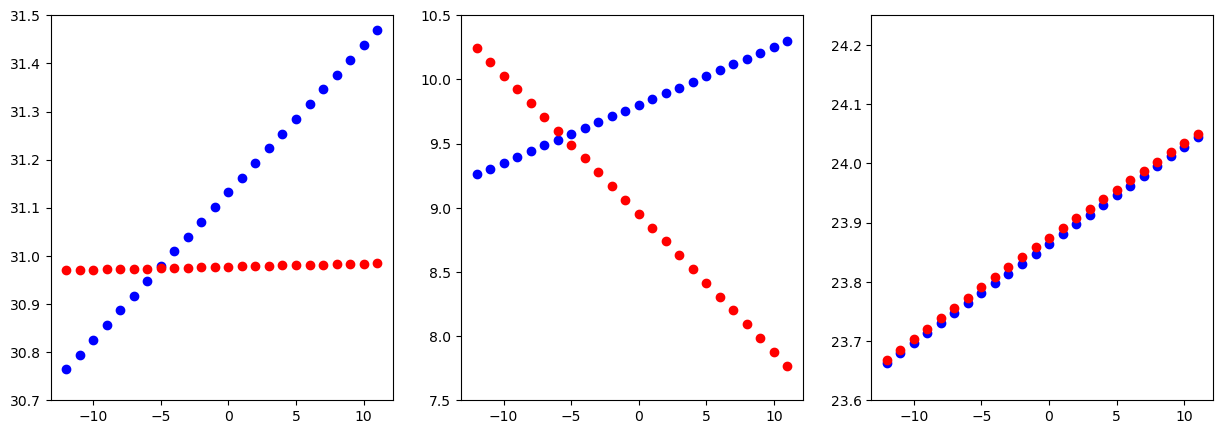

In [127]:
dd, ll = 5, 192
axs = time_change(dd, ll, data19=data19, data18=data18)
axs[0].set_ylim(30.7, 31.5)
axs[1].set_ylim(7.5, 10.5)
axs[2].set_ylim(23.6, 24.25);

In [100]:
orig18 = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2019m02d18.nc')
orig19 = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2019m02d19.nc')

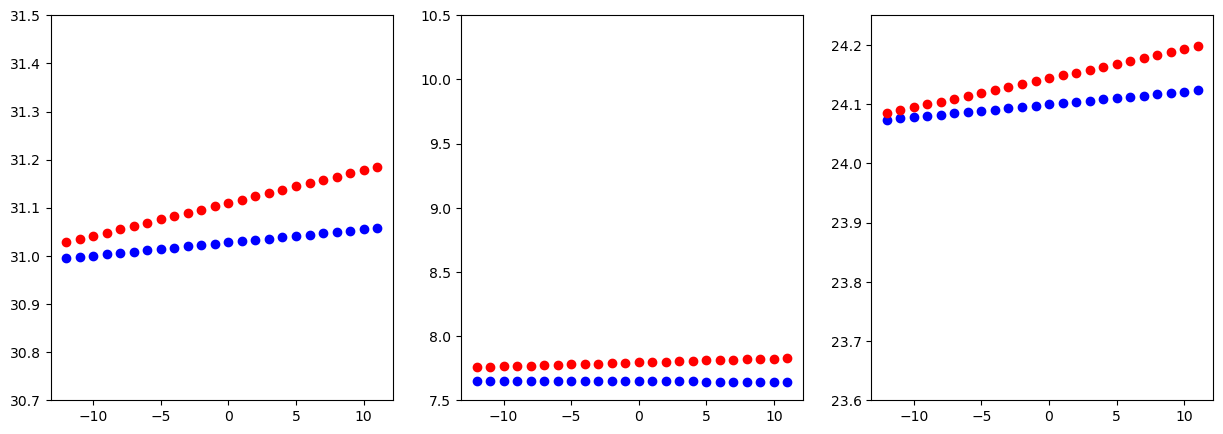

In [128]:
axs = time_change(dd=5, ll=192, data19=orig19, data18=orig18)
axs[0].set_ylim(30.7, 31.5)
axs[1].set_ylim(7.5, 10.5)
axs[2].set_ylim(23.6, 24.25);

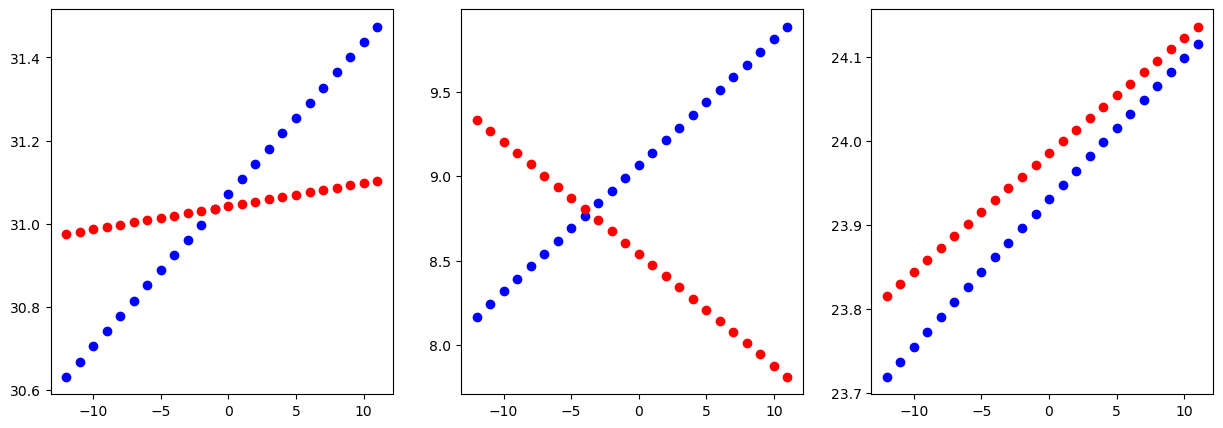

In [103]:
time_change(dd=7, ll=95, data19=data19, data18=data18)

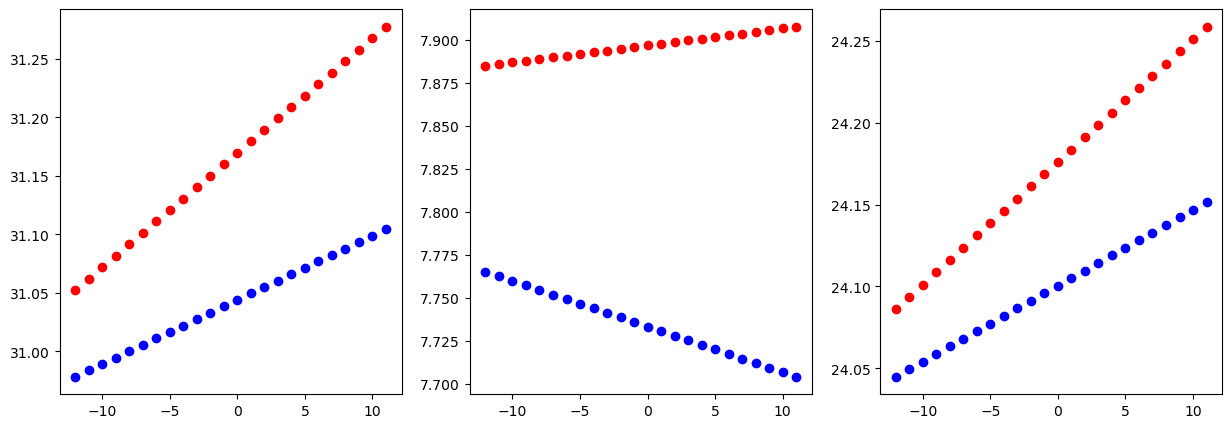

In [104]:
time_change(dd=7, ll=95, data19=orig19, data18=orig18)

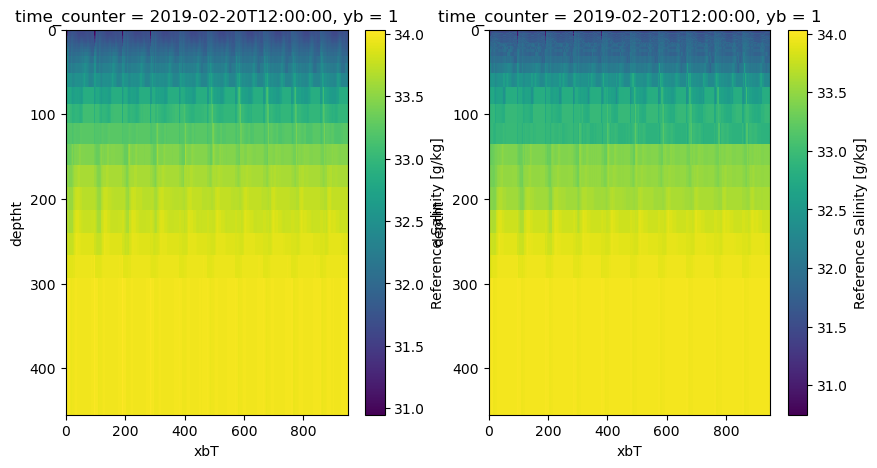

In [107]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
data19.vosaline[0, :, 0].plot(ax=axs[1], yincrease=False)
orig19.vosaline[0, :, 0].plot(ax=axs[0], yincrease=False);

In [108]:
diffy_orig = np.array(orig19.vosaline[0, 1:, 0]) - np.array(orig19.vosaline[0, :-1, 0])

/tmp/ipykernel_2150954/3746290347.py:4: UserWarning: The following kwargs were not used by contour: 'colours'
  axs[0].contour(diffy_orig, levels=[-0.05], colours='k')
/tmp/ipykernel_2150954/3746290347.py:7: UserWarning: The following kwargs were not used by contour: 'colours'
  axs[1].contour(diffy, levels=[-0.05], colours='k')


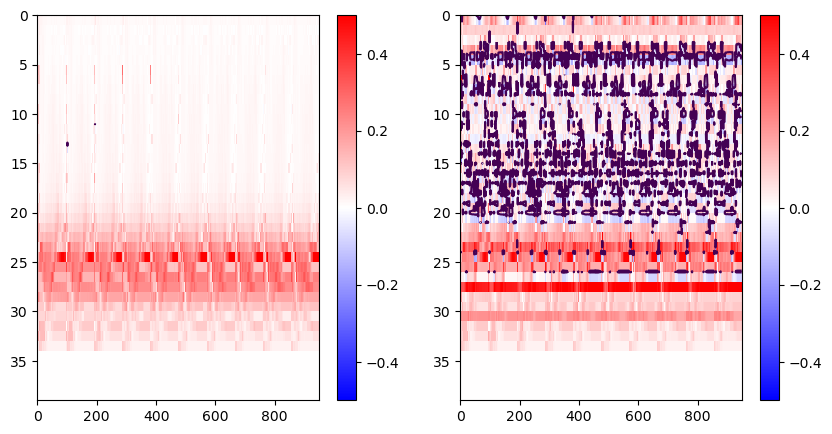

In [117]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
colours = axs[0].pcolormesh(diffy_orig, cmap='bwr', vmax=0.5, vmin=-0.5)
fig.colorbar(colours, ax=axs[0]);
axs[0].contour(diffy_orig, levels=[-0.05], colours='k')
colours = axs[1].pcolormesh(diffy, cmap='bwr', vmax=0.5, vmin=-0.5)
fig.colorbar(colours, ax=axs[1]);
axs[1].contour(diffy, levels=[-0.05], colours='k')

for ax in axs:
    ax.invert_yaxis()

## Becca's Boundary Conditions with Smoothing ##

In [130]:
ndata = xr.open_dataset('LiveOcean_v201905_y2018m01d01.nc')

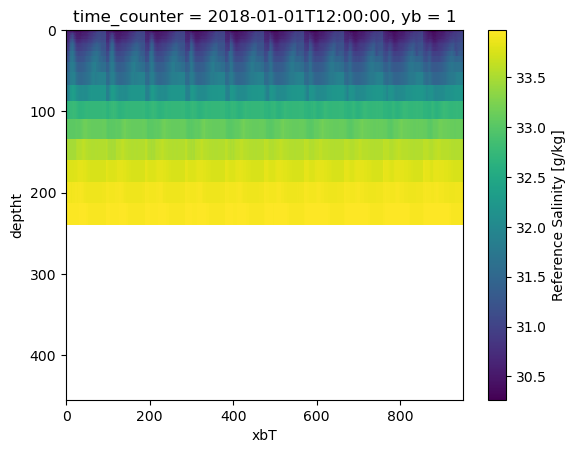

In [132]:
ndata.vosaline[0, :, 0].plot(yincrease=False);